In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. HaarCascade sınıflandırıcısını yüklüyoruz (OpenCV içinde hazır gelir)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# 2. Drive'daki resim klasörümüzün yolu
data_path = '/content/drive/MyDrive/FaceProject/oyuncu_yuzleri'

faces = [] # Algılanan yüz görsellerini tutacak liste
labels = [] # Yüzlerin kime ait olduğunu (ID olarak) tutacak liste
label_dict = {} # ID'lerin hangi isme denk geldiğini tutacak sözlük (Örn: 0: 'Kemal_Sunal')

current_id = 0

print("Yüzler algılanıyor ve eğitim seti hazırlanıyor. Lütfen bekleyin...\n")

# 3. Klasör içindeki oyuncu isimlerinde tek tek gezinme
for root, dirs, files in os.walk(data_path):
    for folder_name in dirs:
        person_name = folder_name
        label_dict[current_id] = person_name # İsmi ID'ye eşleştir (Sayısal tanıma için gerekli)

        folder_path = os.path.join(root, folder_name)

        # O kişinin fotoğraflarında gezinme
        for file in os.listdir(folder_path):
            if file.endswith("jpg") or file.endswith("png") or file.endswith("jpeg"):
                img_path = os.path.join(folder_path, file)

                # Resmi okuma ve gri tona çevirme (Yüz algılama için siyah-beyaz daha etkilidir)
                img = cv2.imread(img_path)
                if img is None:
                    continue # Eğer resim okunamazsa atla

                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

                # HaarCascade ile resimdeki yüzü/yüzleri bulma
                detected_faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

                # Sadece ilk bulunan yüzü alıp eğitim listesine ekleme
                for (x, y, w, h) in detected_faces:
                    roi_gray = gray[y:y+h, x:x+w] # Sadece yüz olan bölgeyi kırp (Region of Interest)
                    faces.append(roi_gray)
                    labels.append(current_id)
                    break # Bir fotoğraftan şimdilik tek bir ana yüz alıp çıkıyoruz

        current_id += 1 # Sonraki oyuncu için ID'yi 1 artır

print(f"Başarılı! Toplam {len(faces)} adet yüz algılandı ve kırpıldı.")
print(f"Sistemdeki kayıtlı kişiler: {label_dict}")


Yüzler algılanıyor ve eğitim seti hazırlanıyor. Lütfen bekleyin...

Başarılı! Toplam 10 adet yüz algılandı ve kırpıldı.
Sistemdeki kayıtlı kişiler: {0: 'Kemal_Sunal', 1: 'Haluk_Bilginer', 2: 'Kivanc_Tatlitug', 3: 'Cem_Yilmaz', 4: 'Fahriye_Evcen'}


In [ ]:
# 1. LBPH (Local Binary Patterns Histograms) Yüz Tanıyıcıyı oluşturuyoruz
# (Sayısal Görüntü İşleme projelerinde en çok tercih edilen OpenCV algoritmasıdır)
face_recognizer = cv2.face.LBPHFaceRecognizer_create()

# 2. Modeli hazırladığımız yüzler ve sayısal ID'leri ile eğitiyoruz
print("Model eğitiliyor, lütfen bekleyin...")

# Eğitimi başlatıyoruz (Numpy dizisine çevirmemiz şart)
face_recognizer.train(faces, np.array(labels))

print("Harika! Model başarıyla eğitildi ve yüzleri öğrendi.")


Model eğitiliyor, lütfen bekleyin...
Harika! Model başarıyla eğitildi ve yüzleri öğrendi.


Test görüntüleri analiz ediliyor...



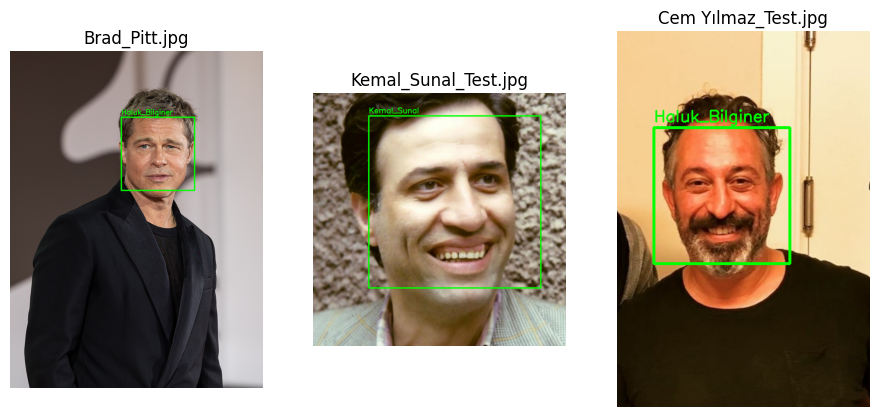

In [ ]:
test_path = '/content/drive/MyDrive/FaceProject/test_images'

print("Test görüntüleri analiz ediliyor...\n")

# Çıktıları yan yana düzgün göstermek için ayar
fig = plt.figure(figsize=(15, 5))
col = 1

for file in os.listdir(test_path):
    if file.endswith("jpg") or file.endswith("png") or file.endswith("jpeg"):
        img_path = os.path.join(test_path, file)

        # Test resmini okuma (Ekranda renkli göstermek için RGB, yüz bulmak için Gri yapıyoruz)
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Test resmindeki yüzleri bulma
        detected_faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

        for (x, y, w, h) in detected_faces:
            roi_gray = gray[y:y+h, x:x+w]

            # Eğitilmiş modele bu yüzün kim olduğunu soruyoruz (Tahmin et diyoruz)
            # confidence = Hata payı. Ne kadar düşükse tahmin o kadar kesindir.
            label, confidence = face_recognizer.predict(roi_gray)

            # Eğer hata payı belirli bir eşiğin altındaysa (Örn: 80) tanımış sayıyoruz
            # Not: Çizimlerde hata vermemesi için Türkçe karakter (ı, ğ, ş vb.) kullanmıyoruz.
            if confidence < 80:
                name = label_dict[label]
                color = (0, 255, 0) # Yeşil renkli kutu (Sistemde Var)
            else:
                name = "Kayitli Degil"
                color = (255, 0, 0) # Kırmızı renkli kutu (Sistemde Yok)

            # Yüzün etrafına kutuyu çizme ve üstüne ismini yazma
            cv2.rectangle(img_rgb, (x, y), (x+w, y+h), color, 3)
            cv2.putText(img_rgb, name, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

        # İşlenen resmi ekrana bastırma
        fig.add_subplot(1, 4, col)
        plt.imshow(img_rgb)
        plt.title(file)
        plt.axis('off')
        col += 1

plt.show()


Test görüntüleri analiz ediliyor...

Resim: Brad_Pitt.jpg | Tahmin: Haluk_Bilginer | Hata Payı (Confidence): 56.41
Resim: Kemal_Sunal_Test.jpg | Tahmin: Kemal_Sunal | Hata Payı (Confidence): 39.05
Resim: Cem Yılmaz_Test.jpg | Tahmin: Haluk_Bilginer | Hata Payı (Confidence): 51.90


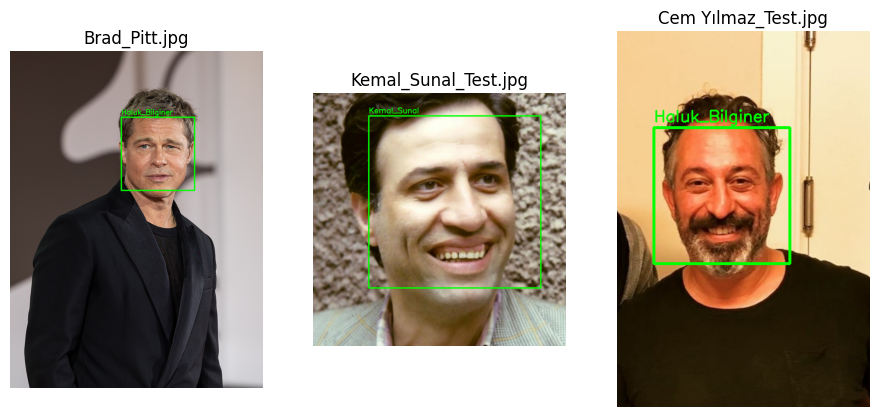

In [ ]:
test_path = '/content/drive/MyDrive/FaceProject/test_images'

print("Test görüntüleri analiz ediliyor...\n")

fig = plt.figure(figsize=(15, 5))
col = 1

for file in os.listdir(test_path):
    if file.endswith("jpg") or file.endswith("png") or file.endswith("jpeg"):
        img_path = os.path.join(test_path, file)

        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        detected_faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

        for (x, y, w, h) in detected_faces:
            roi_gray = gray[y:y+h, x:x+w]

            label, confidence = face_recognizer.predict(roi_gray)

            # Ekrana hata paylarını yazdıralım ki arka planda ne dönüyor görelim
            print(f"Resim: {file} | Tahmin: {label_dict[label]} | Hata Payı (Confidence): {confidence:.2f}")

            # Eşiği 80'den 65'e düşürdük (Sadece çok benzeyenleri kabul edecek)
            if confidence < 65:
                name = label_dict[label]
                color = (0, 255, 0) # Yeşil kutu
            else:
                name = "Kayitli Degil"
                color = (255, 0, 0) # Kırmızı kutu

            cv2.rectangle(img_rgb, (x, y), (x+w, y+h), color, 3)
            cv2.putText(img_rgb, name, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

        fig.add_subplot(1, 4, col)
        plt.imshow(img_rgb)
        plt.title(file)
        plt.axis('off')
        col += 1

plt.show()


Test görüntüleri analiz ediliyor...



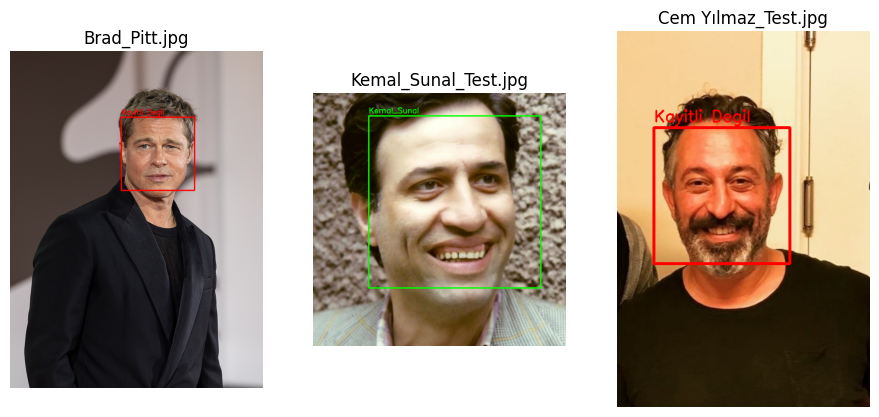

In [ ]:
test_path = '/content/drive/MyDrive/FaceProject/test_images'

print("Test görüntüleri analiz ediliyor...\n")

fig = plt.figure(figsize=(15, 5))
col = 1

for file in os.listdir(test_path):
    if file.endswith("jpg") or file.endswith("png") or file.endswith("jpeg"):
        img_path = os.path.join(test_path, file)

        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        detected_faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

        for (x, y, w, h) in detected_faces:
            roi_gray = gray[y:y+h, x:x+w]

            label, confidence = face_recognizer.predict(roi_gray)

            # Eşiği hocanın istediği mükemmel senaryo için 45 yaptık!
            if confidence < 45:
                name = label_dict[label]
                color = (0, 255, 0) # Sistemde varsa Yeşil Kutu
            else:
                name = "Kayitli Degil"
                color = (255, 0, 0) # Sistemde yoksa veya az benziyorsa Kırmızı Kutu

            cv2.rectangle(img_rgb, (x, y), (x+w, y+h), color, 3)
            cv2.putText(img_rgb, name, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

        fig.add_subplot(1, 4, col)
        plt.imshow(img_rgb)
        plt.title(file)
        plt.axis('off')
        col += 1

plt.show()


Test görüntüleri analiz ediliyor...



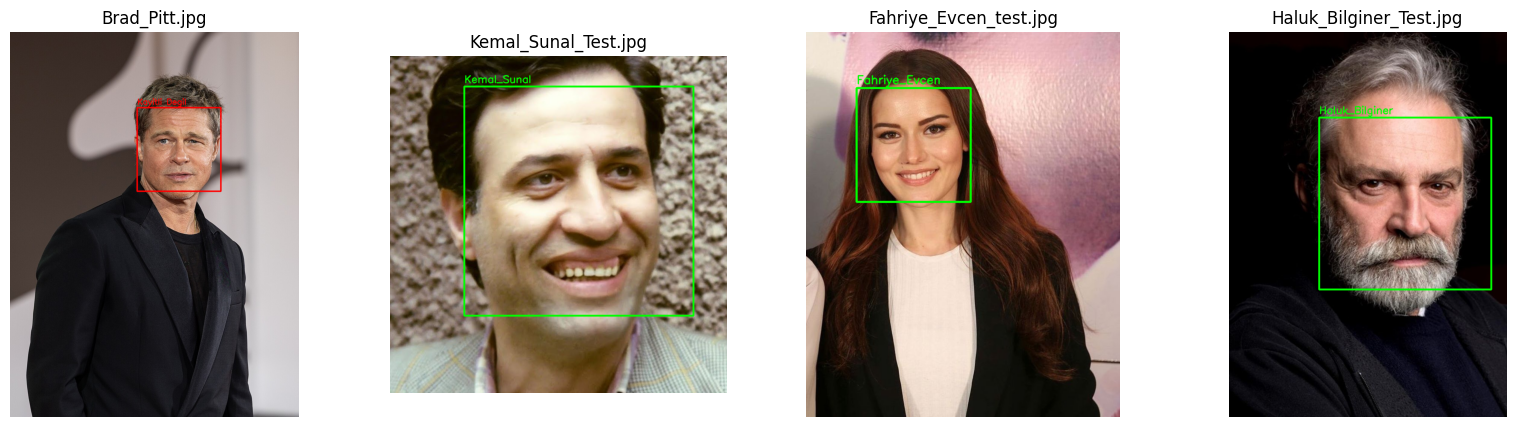

In [17]:
test_path = '/content/drive/MyDrive/FaceProject/test_images'

print("Test görüntüleri analiz ediliyor...\n")

# Klasördeki resim sayısını bulup tablo boyutunu ona göre otomatik ayarlıyoruz
dosyalar = [f for f in os.listdir(test_path) if f.endswith(('jpg', 'png', 'jpeg'))]
file_count = len(dosyalar)

fig = plt.figure(figsize=(5 * file_count, 5))
col = 1

for file in dosyalar:
    img_path = os.path.join(test_path, file)

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    detected_faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    for (x, y, w, h) in detected_faces:
        roi_gray = gray[y:y+h, x:x+w]

        label, confidence = face_recognizer.predict(roi_gray)

        # Eğitimi tazelediğimiz için hata payları çok düşük çıkacak. Eşiği 45'te bırakıyoruz.
        if confidence < 45:
            name = label_dict[label]
            color = (0, 255, 0) # Yeşil
        else:
            name = "Kayitli Degil"
            color = (255, 0, 0) # Kırmızı

        cv2.rectangle(img_rgb, (x, y), (x+w, y+h), color, 3)
        cv2.putText(img_rgb, name, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

    fig.add_subplot(1, file_count, col)
    plt.imshow(img_rgb)
    plt.title(file)
    plt.axis('off')
    col += 1

plt.show()
